# Conditional GMM (Submodal): Diversity + Classifier Guidance

Four sampling procedures compared per class:
1. DDPM baseline
2. Classifier guidance only
3. Diversity only (particle grad)
4. Combined (diversity + classifier)

In [6]:
import sys
sys.path.insert(0, '..')
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from diffusion.scheduler import NoiseScheduler, reverse_step
from salience.sampler import SalientSampler
from salience.phi import DiversityPhi
from experiments.conditional_gmm import (
    make_conditional_gmm, NoisyClassifier,
    train_noisy_classifier, sample_classifier_guided,
)
from experiments.checkpoints import load_model, save_checkpoint
from experiments.comparison import save_samples, save_figure

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

OUTPUTS_DIR = Path('../outputs')
SAMPLES_DIR = OUTPUTS_DIR / 'sampling_results' / 'samples' / 'classifier_guidance_submodal'
PLOTS_DIR   = OUTPUTS_DIR / 'sampling_results' / 'plots' / 'classifier_guidance_submodal'
OUTPUTS_DIR.mkdir(exist_ok=True)

Device: mps


/Users/keesvanhemmen/PycharmProjects/SalienceSensitiveDiffusion/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Build the GMM

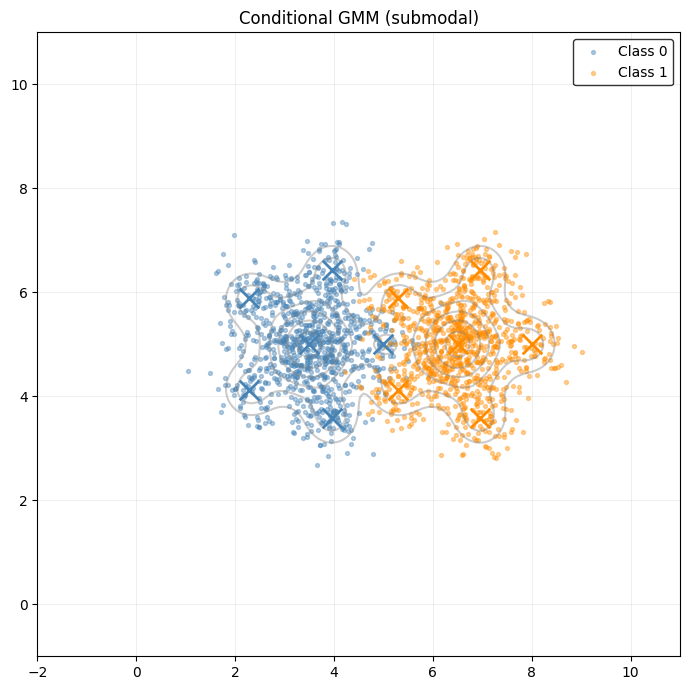

In [19]:
gmm = make_conditional_gmm(device=DEVICE, shape="submodal")

x_vis, y_vis = gmm.sample(2000)
x_vis_np = x_vis.cpu().numpy()
y_vis_np = y_vis.cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 7))

fig.set_facecolor('white')
plt.rcParams.update({
            'text.color': 'black',
            'axes.labelcolor': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'axes.edgecolor': 'black',
            'legend.labelcolor': 'black',
            'legend.edgecolor': 'black',
            'legend.facecolor': 'white',
        })
gmm.contour_plot(colors="gray", alpha=0.4, xlim=(-2, 11))
for c, color, label in [(0, "steelblue", "Class 0"), (1, "darkorange", "Class 1")]:
    mask = y_vis_np == c
    ax.scatter(x_vis_np[mask, 0], x_vis_np[mask, 1], s=8, alpha=0.4,
               color=color, label=label)
modes = gmm.mode_centres().cpu().numpy()
ax.scatter(modes[:6, 0], modes[:6, 1], s=200, marker="x",
           color="steelblue", linewidths=2, zorder=5)
ax.scatter(modes[6:, 0], modes[6:, 1], s=200, marker="x",
           color="darkorange", linewidths=2, zorder=5)
ax.legend()
ax.set_facecolor('white')
ax.set_title("Conditional GMM (submodal)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Train or load the denoising model

In [20]:
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm
from diffusion.model import MLP

T = 1000
noise_scheduler = NoiseScheduler(num_timesteps=T).to(DEVICE)
MODEL_PATH = OUTPUTS_DIR / 'conditional_gmm_model_submodal.pt'

if MODEL_PATH.exists():
    model = load_model(MODEL_PATH, device=DEVICE)
    print('Loaded existing model.')
else:
    data, _ = gmm.sample(50_000)
    loader = DataLoader(TensorDataset(data.float()), shuffle=True, batch_size=256)
    model = MLP(hidden_size=128, hidden_layers=3, emb_size=128,
                time_emb='sinusoidal', input_emb='identity').to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    for epoch in tqdm(range(200)):
        model.train()
        for (x0,) in loader:
            x0 = x0.to(DEVICE)
            t = torch.randint(0, T, (x0.shape[0],), device=DEVICE).long()
            noise = torch.randn_like(x0)
            noisy = noise_scheduler.add_noise(x0, noise, t)
            loss = F.mse_loss(model(noisy, t), noise)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
    save_checkpoint(model, MODEL_PATH)
    model.eval()
    print('Trained and saved.')

Loaded existing model.


## 3. Train or load the noisy classifier

In [21]:
CLASSIFIER_PATH = OUTPUTS_DIR / 'conditional_gmm_classifier_submodal.pt'

if CLASSIFIER_PATH.exists():
    classifier = NoisyClassifier().to(DEVICE)
    classifier.load_state_dict(torch.load(CLASSIFIER_PATH, map_location=DEVICE))
    classifier.eval()
    print('Loaded existing classifier.')
else:
    classifier = train_noisy_classifier(
        gmm=gmm, scheduler=noise_scheduler, device=DEVICE,
        n_train=100_000, epochs=50, save_path=CLASSIFIER_PATH,
    )

Loaded existing classifier.


## 4. Verify classifier on clean data

In [22]:
x_test, y_test = gmm.sample(2000)
t_zero = torch.zeros(2000, device=DEVICE, dtype=torch.long)
with torch.no_grad():
    logits = classifier(x_test, t_zero)
acc = (logits.argmax(dim=-1) == y_test).float().mean().item()
print(f'Clean accuracy (t=0): {acc:.3f}')

Clean accuracy (t=0): 0.955


## 5. Setup

In [23]:
torch.manual_seed(0)
x_init = torch.randn(256, 2, device=DEVICE)
x_init_cls0 = x_init[:128]
x_init_cls1 = x_init[128:]

phi_diversity = DiversityPhi()
sampler = SalientSampler(
    model=model, scheduler=noise_scheduler,
    phi=phi_diversity, device=DEVICE, guidance_frequency=1,
)

## 6. Run all four samplers

In [13]:
# 1. DDPM baseline
print('1/4 DDPM baseline...')
@torch.no_grad()
def sample_ddpm(x_init):
    x = x_init.clone()
    for t in reversed(range(T)):
        x = reverse_step(model, noise_scheduler, x, t)
    return x

x0_base_cls0 = sample_ddpm(x_init_cls0)
x0_base_cls1 = sample_ddpm(x_init_cls1)
print('Done.')

1/4 DDPM baseline...
Done.


In [14]:
# 2. Classifier guidance only
print('2/4 Classifier guidance...')
x0_cls_cls0 = sample_classifier_guided(
    model=model, classifier=classifier, scheduler=noise_scheduler,
    x_init=x_init_cls0, target_class=0, guidance_scale=1.0, verbose=True,
)
x0_cls_cls1 = sample_classifier_guided(
    model=model, classifier=classifier, scheduler=noise_scheduler,
    x_init=x_init_cls1, target_class=1, guidance_scale=1.0, verbose=True,
)
print('Done.')

2/4 Classifier guidance...
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
Done.


In [15]:
# 3. Diversity only
print('3/4 Diversity guidance...')
x0_div_cls0 = sampler.sample_particle_grad_guided(
    x_init_cls0, guidance_scale=1.0, verbose=True,
)
x0_div_cls1 = sampler.sample_particle_grad_guided(
    x_init_cls1, guidance_scale=1.0, verbose=True,
)
print('Done.')

3/4 Diversity guidance...
  t = 999
  t = 998
  t = 997
  t = 996
  t = 995
  t = 994
  t = 993
  t = 992
  t = 991
  t = 990
  t = 989
  t = 988
  t = 987
  t = 986
  t = 985
  t = 984
  t = 983
  t = 982
  t = 981
  t = 980
  t = 979
  t = 978
  t = 977
  t = 976
  t = 975
  t = 974
  t = 973
  t = 972
  t = 971
  t = 970
  t = 969
  t = 968
  t = 967
  t = 966
  t = 965
  t = 964
  t = 963
  t = 962
  t = 961
  t = 960
  t = 959
  t = 958
  t = 957
  t = 956
  t = 955
  t = 954
  t = 953
  t = 952
  t = 951
  t = 950
  t = 949
  t = 948
  t = 947
  t = 946
  t = 945
  t = 944
  t = 943
  t = 942
  t = 941
  t = 940
  t = 939
  t = 938
  t = 937
  t = 936
  t = 935
  t = 934
  t = 933
  t = 932
  t = 931
  t = 930
  t = 929
  t = 928
  t = 927
  t = 926
  t = 925
  t = 924
  t = 923
  t = 922
  t = 921
  t = 920
  t = 919
  t = 918
  t = 917
  t = 916
  t = 915
  t = 914
  t = 913
  t = 912
  t = 911
  t = 910
  t = 909
  t = 908
  t = 907
  t = 906
  t = 905
  t = 904
  t = 903
  t 

In [16]:
# 4. Combined
print('4/4 Combined guidance...')
x0_combined_cls0 = sampler.sample_particle_grad_classifier(
    x_init_cls0, classifier=classifier, target_class=0,
    diversity_scale=1.0, classifier_scale=1.0, verbose=True,
)
x0_combined_cls1 = sampler.sample_particle_grad_classifier(
    x_init_cls1, classifier=classifier, target_class=1,
    diversity_scale=1.0, classifier_scale=1.0, verbose=True,
)
print('Done.')

4/4 Combined guidance...
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
Done.


## 7. Save samples

In [17]:
save_samples(torch.cat([x0_base_cls0,     x0_base_cls1]),
             'conditional_ddpm_baseline',      SAMPLES_DIR)
save_samples(torch.cat([x0_cls_cls0,      x0_cls_cls1]),
             'conditional_classifier_guided',  SAMPLES_DIR)
save_samples(torch.cat([x0_div_cls0,      x0_div_cls1]),
             'conditional_diversity_only',     SAMPLES_DIR)
save_samples(torch.cat([x0_combined_cls0, x0_combined_cls1]),
             'conditional_combined_guidance',  SAMPLES_DIR)

Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/conditional_ddpm_baseline.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/conditional_ddpm_baseline.npy
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/conditional_classifier_guided.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/conditional_classifier_guided.npy
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/conditional_diversity_only.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/conditional_diversity_only.npy
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/conditional_combined_guidance.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/conditional_combined_guidance.npy


In [3]:
import torch
from pathlib import Path

SAMPLES_DIR = Path("../outputs/sampling_results/samples/classifier_guidance_submodal")

def load_split(name, n_cls0=128):
    samples = torch.load(SAMPLES_DIR / f"{name}.pt", map_location="cpu")
    return samples[:n_cls0], samples[n_cls0:]

x0_base_cls0,     x0_base_cls1     = load_split("conditional_ddpm_baseline")
x0_cls_cls0,      x0_cls_cls1      = load_split("conditional_classifier_guided")
x0_div_cls0,      x0_div_cls1      = load_split("conditional_diversity_only")
x0_combined_cls0, x0_combined_cls1 = load_split("conditional_combined_guidance")

## 8. Comparison figure

Saved figure  -> ../outputs/sampling_results/plots/classifier_guidance_submodal/conditional_comparison_all_samplers.png


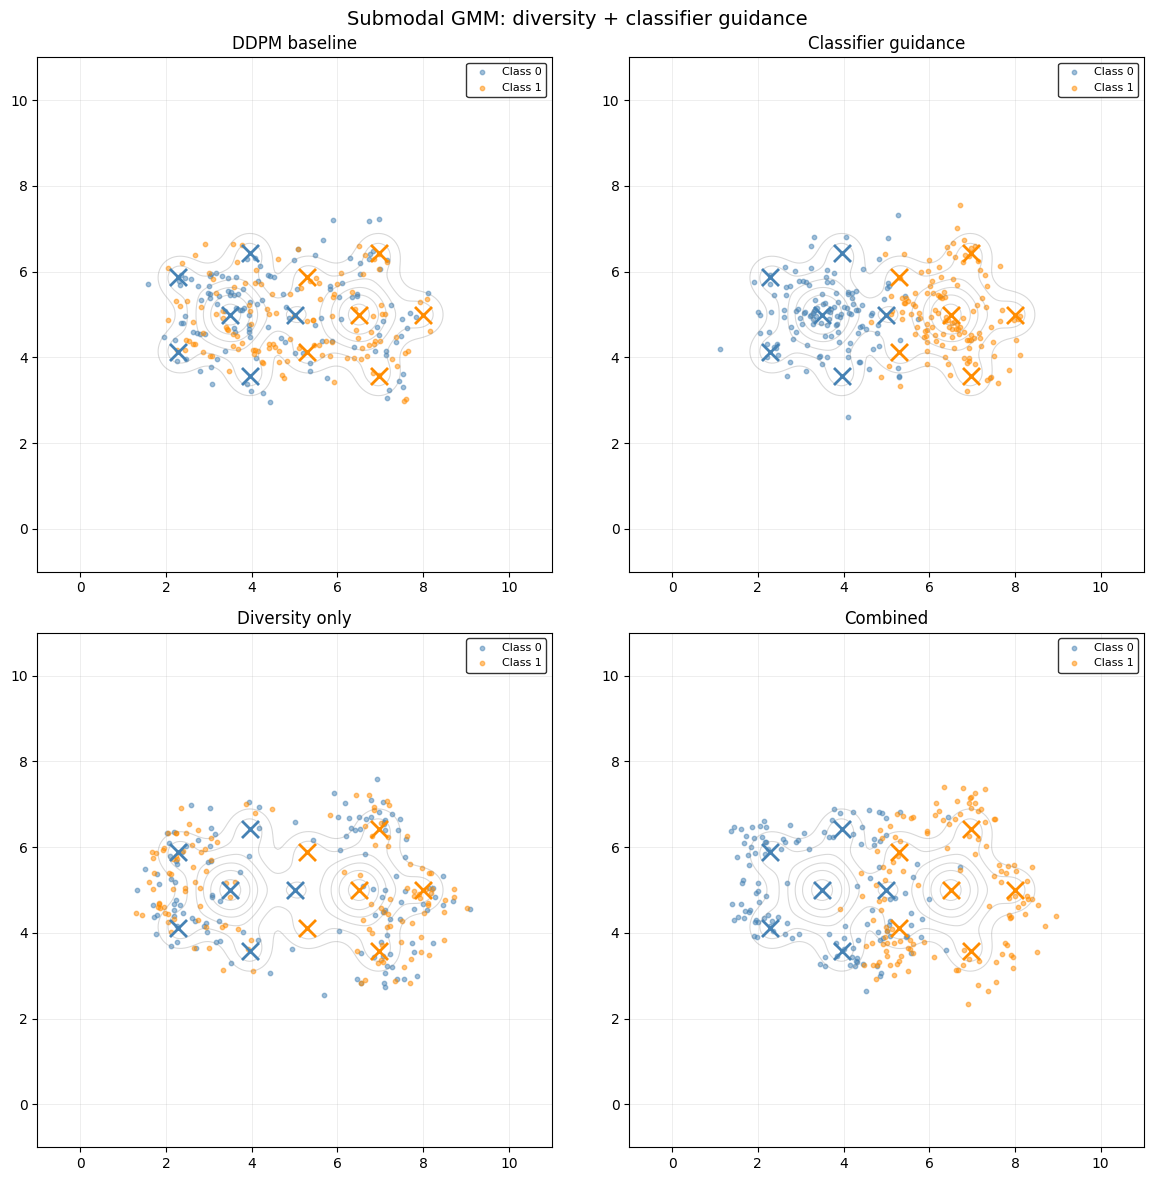

In [17]:
def plot_conditional_comparison(sample_pairs, gmm, suptitle):
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()
    modes = gmm.mode_centres().cpu().numpy()
    fig.set_facecolor('white')
    plt.rcParams.update({
            'text.color': 'black',
            'axes.labelcolor': 'black',
            'xtick.color': 'black',
            'ytick.color': 'black',
            'axes.edgecolor': 'black',
            'legend.labelcolor': 'black',
            'legend.edgecolor': 'black',
            'legend.facecolor': 'white',
        })

    for ax, (title, c0, c1) in zip(axes, sample_pairs):
        plt.sca(ax)
        gmm.contour_plot(colors='gray', alpha=0.3, linewidths=0.8)
        c0_np = c0.detach().cpu().numpy()
        c1_np = c1.detach().cpu().numpy()
        ax.scatter(c0_np[:,0], c0_np[:,1], s=10, alpha=0.5,
                   color='steelblue', label='Class 0')
        ax.scatter(c1_np[:,0], c1_np[:,1], s=10, alpha=0.5,
                   color='darkorange', label='Class 1')
        ax.scatter(modes[:6,0], modes[:6,1], s=150, marker='x',
                   color='steelblue', linewidths=2, zorder=5)
        ax.scatter(modes[6:,0], modes[6:,1], s=150, marker='x',
                   color='darkorange', linewidths=2, zorder=5)
        ax.set_title(title, fontsize=12)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)
        ax.set_facecolor('white')


    fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    return fig

fig = plot_conditional_comparison(
    sample_pairs=[
        ('DDPM baseline',       x0_base_cls0,     x0_base_cls1),
        ('Classifier guidance', x0_cls_cls0,      x0_cls_cls1),
        ('Diversity only',      x0_div_cls0,      x0_div_cls1),
        ('Combined',            x0_combined_cls0, x0_combined_cls1),
    ],
    gmm=gmm,
    suptitle='Conditional GMM: diversity + classifier guidance',
)
save_figure(fig, 'conditional_comparison_all_samplers', PLOTS_DIR)
plt.show()

## 9. Classifier accuracy on generated samples

In [25]:
def classifier_accuracy(c0, c1, classifier, device):
    x = torch.cat([c0, c1]).to(device)
    y = torch.cat([
        torch.zeros(c0.shape[0], dtype=torch.long),
        torch.ones(c1.shape[0],  dtype=torch.long),
    ]).to(device)
    t = torch.zeros(x.shape[0], dtype=torch.long, device=device)
    with torch.no_grad():
        preds = classifier(x, t).argmax(dim=-1)
    return (preds == y).float().mean().item()

results = [
    ('DDPM baseline',       x0_base_cls0,     x0_base_cls1),
    ('Classifier guidance', x0_cls_cls0,      x0_cls_cls1),
    ('Diversity only',      x0_div_cls0,      x0_div_cls1),
    ('Combined',            x0_combined_cls0, x0_combined_cls1),
]

print(f'{"Sampler":<25} {"Classifier accuracy":>20}')
print('-' * 47)
for name, c0, c1 in results:
    acc = classifier_accuracy(c0, c1, classifier, DEVICE)
    print(f'{name:<25} {acc:>20.3f}')

Sampler                    Classifier accuracy
-----------------------------------------------
DDPM baseline                            0.531
Classifier guidance                      0.934
Diversity only                           0.469
Combined                                 0.836


## Ablation of guidance scales

In [20]:
# ---------------------------------------------------------------------------
# Ablation: combined guidance scale
# ---------------------------------------------------------------------------
from experiments.comparison import save_figure

C_ABLATION_SCALES = [0.1, 0.5, 1.0, 2.0, 5.0]
D_ABLATION_SCALES = [0.1, 0.5, 1.0, 2.0]

# Results stored as:
# ablation_cls[scale]  = (x0_cls0, x0_cls1)  -- classifier scale ablation
# ablation_div[scale]  = (x0_cls0, x0_cls1)  -- diversity scale ablation
ablation_cls = {}
ablation_div = {}

# --- Classifier scale ablation (diversity fixed at 1.0) ---
print("Classifier scale ablation...")
for s in C_ABLATION_SCALES:
    print(f"  classifier_scale={s}")
    c0 = sampler.sample_particle_grad_classifier(
        x_init_cls0, classifier=classifier, target_class=0,
        diversity_scale=1.0, classifier_scale=s, verbose=False,
    )
    c1 = sampler.sample_particle_grad_classifier(
        x_init_cls1, classifier=classifier, target_class=1,
        diversity_scale=1.0, classifier_scale=s, verbose=False,
    )
    ablation_cls[s] = (c0, c1)
    save_samples(
        torch.cat([c0, c1]),
        name=f"ablation_cls_scale_{str(s).replace('.', 'p')}",
        root=SAMPLES_DIR,
    )

# --- Diversity scale ablation (classifier fixed at 1.0) ---
print("Diversity scale ablation...")
for s in C_ABLATION_SCALES:
    print(f"  diversity_scale={s}")
    c0 = sampler.sample_particle_grad_classifier(
        x_init_cls0, classifier=classifier, target_class=0,
        diversity_scale=s, classifier_scale=1.0, verbose=False,
    )
    c1 = sampler.sample_particle_grad_classifier(
        x_init_cls1, classifier=classifier, target_class=1,
        diversity_scale=s, classifier_scale=1.0, verbose=False,
    )
    ablation_div[s] = (c0, c1)
    save_samples(
        torch.cat([c0, c1]),
        name=f"ablation_div_scale_{str(s).replace('.', 'p')}",
        root=SAMPLES_DIR,
    )

Classifier scale ablation...
  classifier_scale=0.1
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/ablation_cls_scale_0p1.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/ablation_cls_scale_0p1.npy
  classifier_scale=0.5
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/ablation_cls_scale_0p5.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/ablation_cls_scale_0p5.npy
  classifier_scale=1.0
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/ablation_cls_scale_1p0.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/ablation_cls_scale_1p0.npy
  classifier_scale=2.0
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/ablation_cls_scale_2p0.pt
Saved samples -> ../outputs/sampling_results/samples/classifier_guidance_submodal/ablation_cls_scale_2p0.npy
  classifie

In [21]:
# ---------------------------------------------------------------------------
# Compute metrics for all ablation runs
# ---------------------------------------------------------------------------
from experiments.evaluation import distance_to_nearest_mode
import numpy as np

def compute_ablation_metrics(ablation_dict, classifier, device, gmm):
    """
    For each scale value, compute:
        - classifier accuracy on generated samples
        - mean pairwise diversity
        - mean distance to nearest mode
    Returns dict: {scale: {"accuracy": ..., "diversity": ..., "dist": ...}}
    """
    results = {}
    modes = gmm.mode_centres().cpu().numpy()

    for s, (c0, c1) in ablation_dict.items():
        # Classifier accuracy
        x_all = torch.cat([c0, c1]).to(device)
        y_all = torch.cat([
            torch.zeros(c0.shape[0], dtype=torch.long),
            torch.ones(c1.shape[0],  dtype=torch.long),
        ]).to(device)
        t_zero = torch.zeros(x_all.shape[0], dtype=torch.long, device=device)
        with torch.no_grad():
            preds = classifier(x_all, t_zero).argmax(dim=-1)
        acc = (preds == y_all).float().mean().item()

        # Mean pairwise diversity (per class, then averaged)
        c0_np = c0.detach().cpu().numpy()
        c1_np = c1.detach().cpu().numpy()

        def pairwise(x):
            diff = x[:, None, :] - x[None, :, :]
            dists = np.linalg.norm(diff, axis=-1)
            idx = np.triu_indices(len(x), k=1)
            return dists[idx].mean()

        div = (pairwise(c0_np) + pairwise(c1_np)) / 2.0

        # Mean distance to nearest mode
        dist = (
            distance_to_nearest_mode(c0_np, modes[:5]).mean() +
            distance_to_nearest_mode(c1_np, modes[5:]).mean()
        ) / 2.0

        results[s] = {"accuracy": acc, "diversity": div, "dist": dist}

    return results

metrics_cls = compute_ablation_metrics(ablation_cls, classifier, DEVICE, gmm)
metrics_div = compute_ablation_metrics(ablation_div, classifier, DEVICE, gmm)

# Print tables
for label, metrics in [("Classifier scale (div=1.0)", metrics_cls),
                        ("Diversity scale (cls=1.0)",  metrics_div)]:
    print(f"\n{label}")
    print(f"{'Scale':<8} {'Accuracy':>10} {'Diversity':>12} {'Dist to mode':>14}")
    print("-" * 46)
    for s in C_ABLATION_SCALES:
        m = metrics[s]
        print(f"{s:<8} {m['accuracy']:>10.3f} {m['diversity']:>12.3f} {m['dist']:>14.3f}")


Classifier scale (div=1.0)
Scale      Accuracy    Diversity   Dist to mode
----------------------------------------------
0.1           0.527        3.132          1.275
0.5           0.637        2.706          0.920
1.0           0.840        2.360          0.736
2.0           0.965        2.179          0.720
5.0           1.000        2.109          0.720

Diversity scale (cls=1.0)
Scale      Accuracy    Diversity   Dist to mode
----------------------------------------------
0.1           0.953        1.621          0.620
0.5           0.883        1.979          0.659
1.0           0.820        2.437          0.785
2.0           0.754        2.847          0.968
5.0           0.672        3.834          1.672


Saved figure  -> ../outputs/sampling_results/plots/classifier_guidance_submodal/ablation_classifier_scale_scatter.png


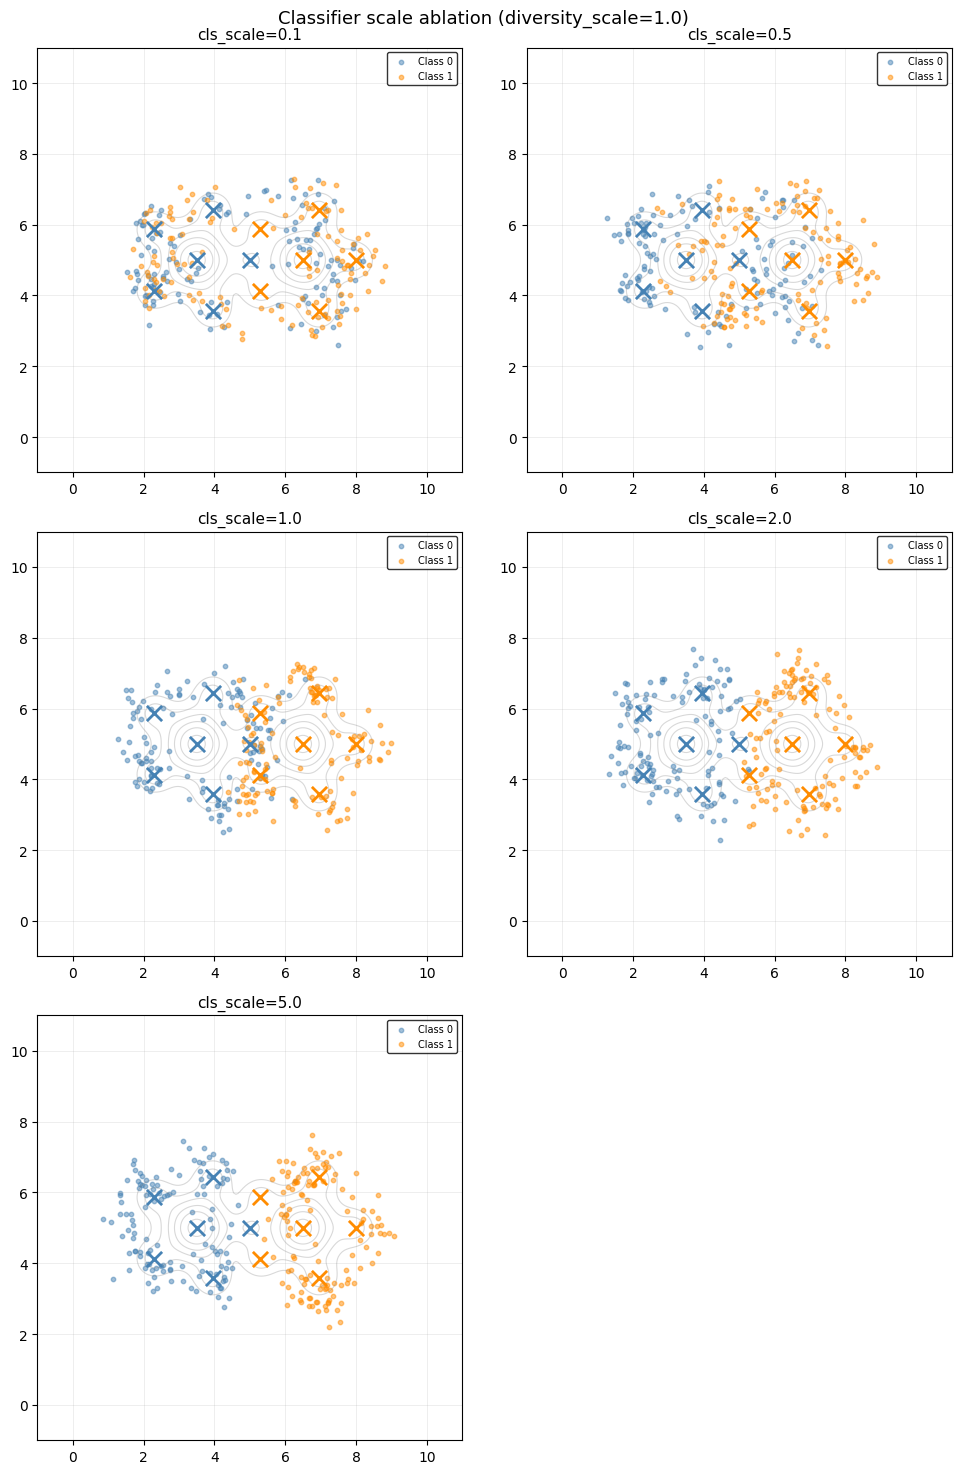

Saved figure  -> ../outputs/sampling_results/plots/classifier_guidance_submodal/ablation_diversity_scale_scatter.png


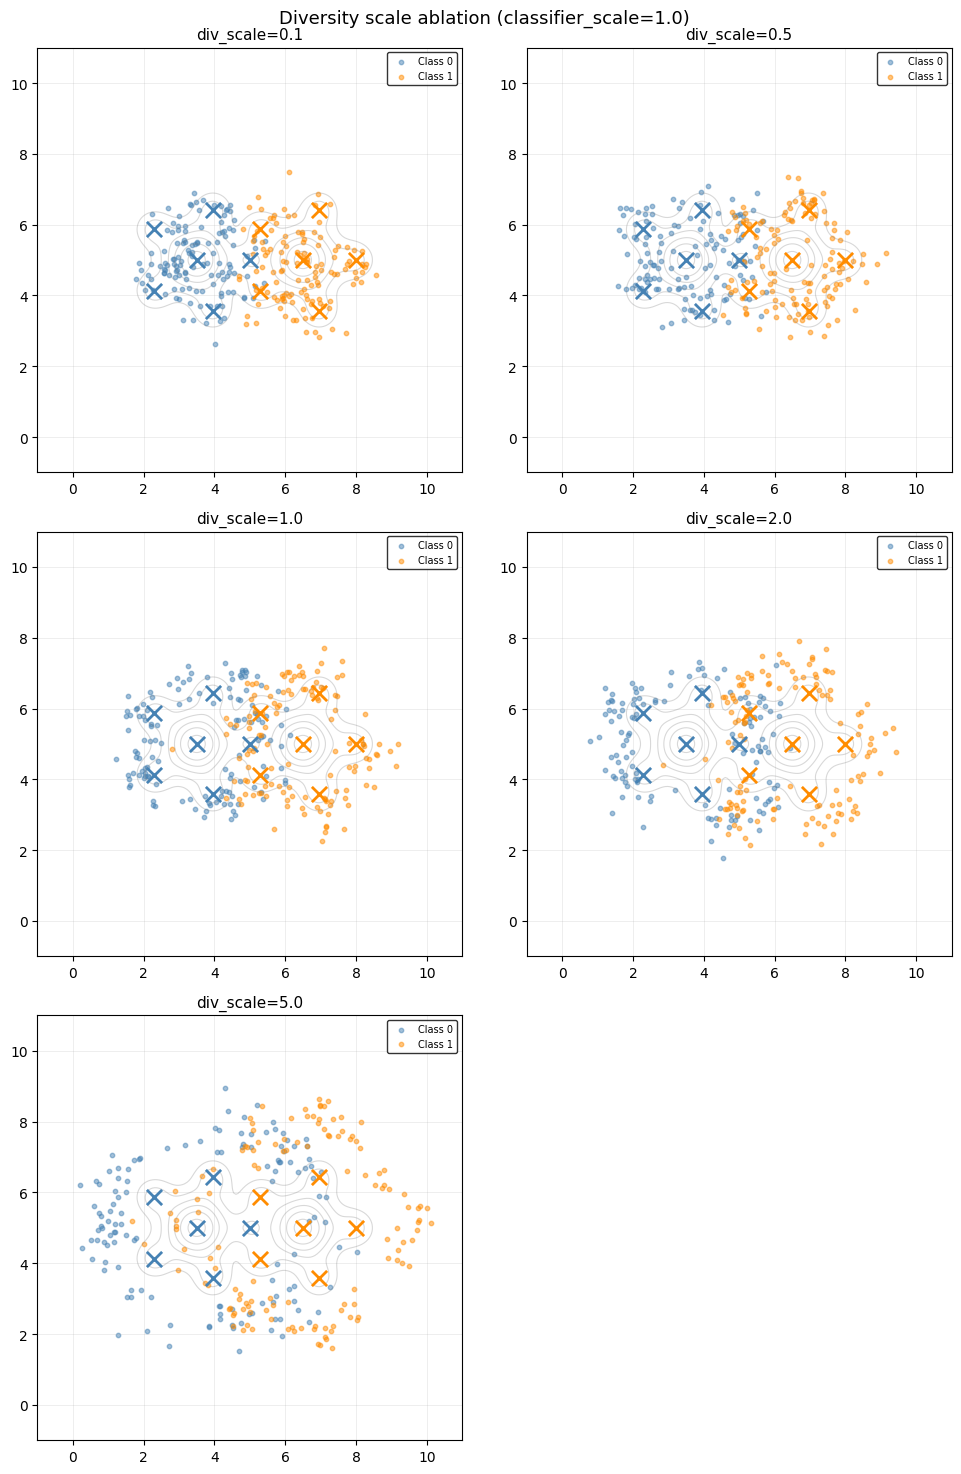

In [26]:
import math
def plot_ablation_scatter(ablation_dict, scales, gmm, title_prefix, suptitle):
    n = len(scales)
    ncols = 2
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows), facecolor='white')
    axes = axes.flatten()
    modes = gmm.mode_centres().cpu().numpy()

    for ax, s in zip(axes, scales):
        ax.set_facecolor('white')
        c0, c1 = ablation_dict[s]
        plt.sca(ax)
        gmm.contour_plot(colors='gray', alpha=0.3, linewidths=0.8)
        ax.scatter(c0.cpu()[:,0], c0.cpu()[:,1], s=10, alpha=0.5,
                   color='steelblue', label='Class 0')
        ax.scatter(c1.cpu()[:,0], c1.cpu()[:,1], s=10, alpha=0.5,
                   color='darkorange', label='Class 1')
        ax.scatter(modes[:6,0], modes[:6,1], s=120, marker='x',
                   color='steelblue', linewidths=2, zorder=5)
        ax.scatter(modes[6:,0], modes[6:,1], s=120, marker='x',
                   color='darkorange', linewidths=2, zorder=5)
        ax.set_title(f"{title_prefix}={s}", fontsize=11, color='black')
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, facecolor='white', edgecolor='black', labelcolor='black')
        ax.tick_params(colors='black')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')

    # Hide any unused axes if n is odd
    for ax in axes[n:]:
        ax.set_visible(False)

    fig.suptitle(suptitle, fontsize=13, color='black')
    plt.tight_layout()
    return fig


fig_cls_scatter = plot_ablation_scatter(
    ablation_cls, C_ABLATION_SCALES, gmm,
    title_prefix="cls_scale",
    suptitle="Classifier scale ablation (diversity_scale=1.0)",
)
save_figure(fig_cls_scatter, "ablation_classifier_scale_scatter", PLOTS_DIR)
plt.show()

fig_div_scatter = plot_ablation_scatter(
    ablation_div, C_ABLATION_SCALES, gmm,
    title_prefix="div_scale",
    suptitle="Diversity scale ablation (classifier_scale=1.0)",
)
save_figure(fig_div_scatter, "ablation_diversity_scale_scatter", PLOTS_DIR)
plt.show()


Saved figure  -> ../outputs/sampling_results/plots/classifier_guidance_submodal/ablation_metric_curves.png


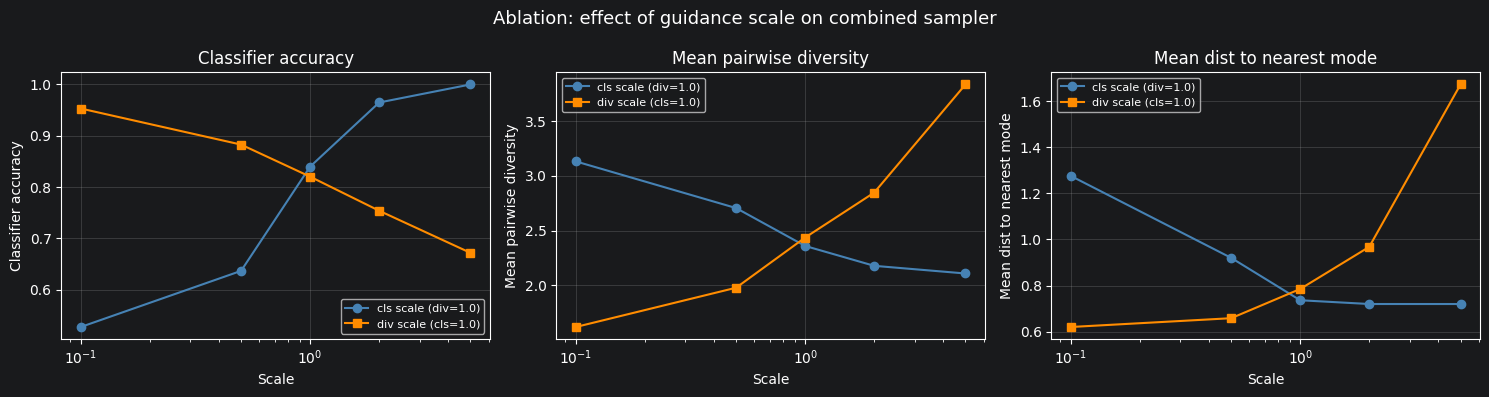

In [28]:
# ---------------------------------------------------------------------------
# Metric curves: accuracy and diversity vs scale
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metric_keys  = ["accuracy",   "diversity",       "dist"]
metric_labels = ["Classifier accuracy", "Mean pairwise diversity", "Mean dist to nearest mode"]

for ax, key, ylabel in zip(axes, metric_keys, metric_labels):
    vals_cls = [metrics_cls[s][key] for s in C_ABLATION_SCALES]
    vals_div = [metrics_div[s][key] for s in C_ABLATION_SCALES]

    ax.plot(C_ABLATION_SCALES, vals_cls, marker='o', label='cls scale (div=1.0)',
            color='steelblue')
    ax.plot(C_ABLATION_SCALES, vals_div, marker='s', label='div scale (cls=1.0)',
            color='darkorange')
    ax.set_xlabel("Scale")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Ablation: effect of guidance scale on combined sampler", fontsize=13)
plt.tight_layout()
save_figure(fig, "ablation_metric_curves", PLOTS_DIR)
plt.show()


In [29]:
import torch
from salience.phi import DiversityPhi

phi = DiversityPhi()

# Library: single point at origin
lib = torch.tensor([[0.0, 0.0]])

# Query points
test_points = [
    torch.tensor([1.0, 0.0]),
    torch.tensor([2.0, 0.0]),
    torch.tensor([0.0, 1.0]),
    torch.tensor([1.0, 1.0]),
]

for x_query in test_points:
    x_query = x_query.requires_grad_(True)
    X_batch = torch.cat([x_query.unsqueeze(0), lib], dim=0)

    with torch.enable_grad():
        phi_vals = phi.forward_batched(X_batch, t=0, context={})
        phi_query = phi_vals[0].squeeze()
        grad, = torch.autograd.grad(phi_query, x_query)
        log_S = 2.0 * torch.log(grad.norm() + 1e-12)

    expected_grad = 2 * x_query.detach()
    expected_log_S = 2.0 * torch.log(expected_grad.norm() + 1e-12)

    print(f"x={x_query.detach().numpy()}")
    print(f"  computed grad:  {grad.detach().numpy()}")
    print(f"  expected grad:  {expected_grad.numpy()}")
    print(f"  computed log_S: {log_S.item():.4f}")
    print(f"  expected log_S: {expected_log_S.item():.4f}")
    print(f"  match: {torch.allclose(grad, expected_grad, atol=1e-4)}")
    print()

x=[1. 0.]
  computed grad:  [2. 0.]
  expected grad:  [2. 0.]
  computed log_S: 1.3863
  expected log_S: 1.3863
  match: True

x=[2. 0.]
  computed grad:  [4. 0.]
  expected grad:  [4. 0.]
  computed log_S: 2.7726
  expected log_S: 2.7726
  match: True

x=[0. 1.]
  computed grad:  [0. 2.]
  expected grad:  [0. 2.]
  computed log_S: 1.3863
  expected log_S: 1.3863
  match: True

x=[1. 1.]
  computed grad:  [2. 2.]
  expected grad:  [2. 2.]
  computed log_S: 2.0794
  expected log_S: 2.0794
  match: True



  Computing salience heatmap at t=900...
  Computing salience heatmap at t=500...
  Computing salience heatmap at t=250...
  Computing salience heatmap at t=50...


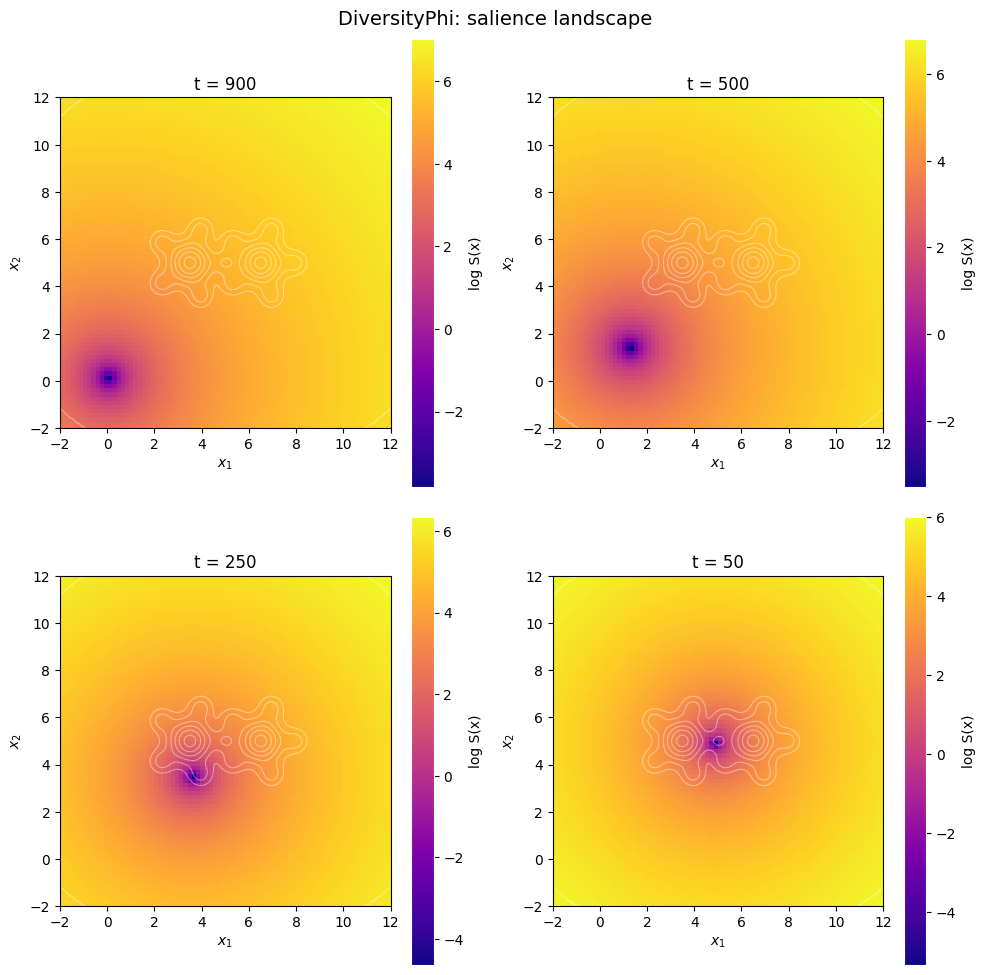

In [30]:
from salience.phi import DiversityPhi
from salience.sampler import SalientSampler
from experiments.visualize_salience import (
    sample_with_trajectory_capture,
    plot_salience_heatmap_clean,
    plot_salience_vector_field_clean,
)

phi_div = DiversityPhi()
context = {}

sampler = SalientSampler(
    model=model, scheduler=noise_scheduler,
    phi=phi_div, device=DEVICE, guidance_frequency=1,
)

_, snaps_guided = sample_with_trajectory_capture(
    sampler=sampler,
    x_T=x_init,
    capture_timesteps=[900, 500, 250, 50],
    guidance_scale=1.0,
    context=context,
)

# Salience heatmap
fig_heatmap = plot_salience_heatmap_clean(
    phi=phi_div,
    timesteps=[900, 500, 250, 50],
    context=context,
    library_snapshots=snaps_guided,
    particle_index=0,
    gmm=gmm,
    device=DEVICE,
    suptitle="DiversityPhi: salience landscape",
)

  Computing salience vector field at t=900...
  Computing salience vector field at t=500...
  Computing salience vector field at t=250...
  Computing salience vector field at t=50...


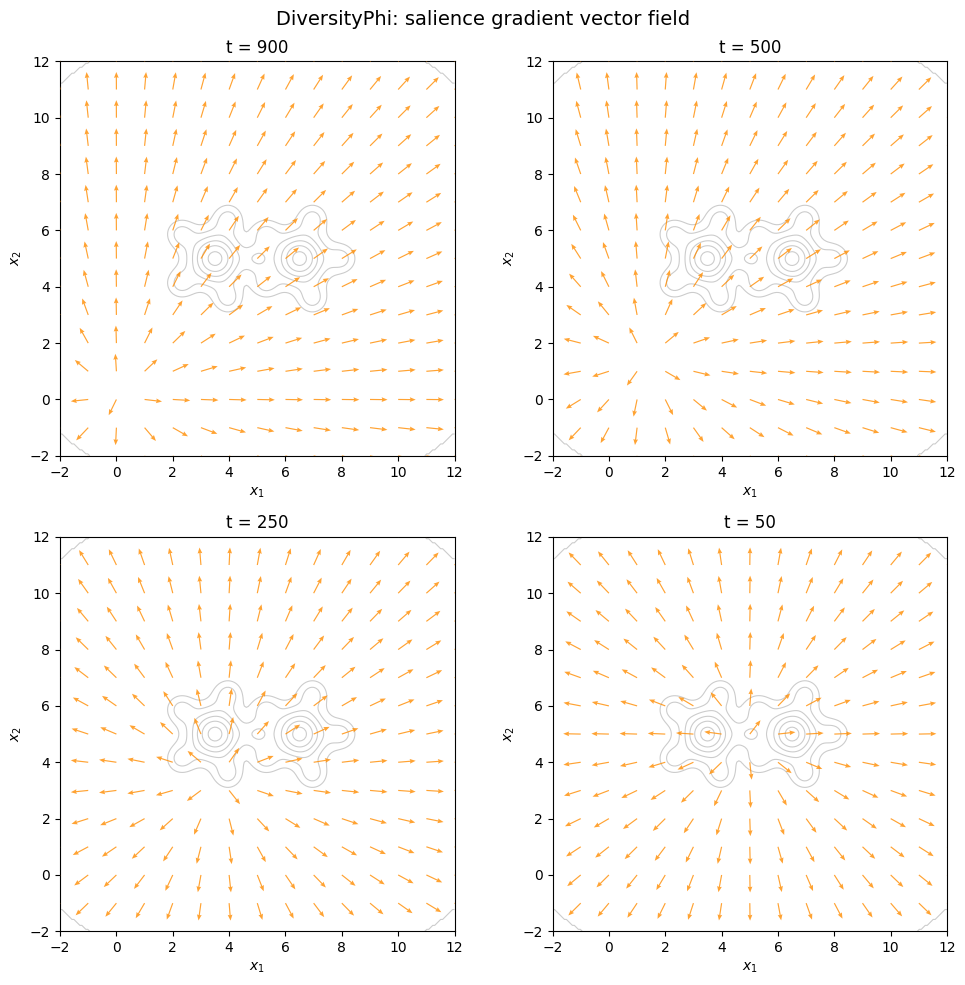

In [31]:
# Vector field
fig_vf = plot_salience_vector_field_clean(
    phi=phi_div,
    timesteps=[900, 500, 250, 50],
    context=context,
    library_snapshots=snaps_guided,
    particle_index=0,
    gmm=gmm,
    device=DEVICE,
    suptitle="DiversityPhi: salience gradient vector field",
)